In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import joblib

In [3]:
## Data Exploration and Preprocessing

# load the dataset
data = pd.read_csv('./data/Student data.csv')

In [4]:
# Check for missing values 
missing_values = data.isnull().sum()
print("Missing values in each column:\n", missing_values)

Missing values in each column:
 Student Data     6
Unnamed: 1      23
Unnamed: 2      23
Unnamed: 3      23
Unnamed: 4      23
Unnamed: 5      23
Unnamed: 6      23
Unnamed: 7      23
Unnamed: 8      23
Unnamed: 9      23
Unnamed: 10     23
Unnamed: 11     23
Unnamed: 12     23
Unnamed: 13     23
Unnamed: 14     23
dtype: int64


In [6]:
# Check for duplicates
duplicates = data.duplicated().sum()
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 6


In [7]:
# Summary of the dataset
print("Dataset summary:\n", data.describe())

Dataset summary:
         Unnamed: 3  Unnamed: 4   Unnamed: 5   Unnamed: 6   Unnamed: 7  \
count  1437.000000      1437.0  1437.000000  1437.000000  1437.000000   
mean      2.926931         6.0     1.741823     1.695198     1.406402   
std       1.257658         0.0     0.437784     0.460484     0.491332   
min       1.000000         6.0     1.000000     1.000000     1.000000   
25%       2.000000         6.0     1.000000     1.000000     1.000000   
50%       2.000000         6.0     2.000000     2.000000     1.000000   
75%       4.000000         6.0     2.000000     2.000000     2.000000   
max       9.000000         6.0     2.000000     2.000000     2.000000   

        Unnamed: 8  Unnamed: 14  
count  1437.000000  1437.000000  
mean      1.774530     0.791928  
std       0.419699     0.406070  
min       1.000000     0.000000  
25%       2.000000     1.000000  
50%       2.000000     1.000000  
75%       2.000000     1.000000  
max       3.000000     1.000000  


In [8]:
## Data Cleaning and Feature Engineering

columns = [
    'First_Term_GPA', 'Second_Term_GPA', 'First_Language', 'Funding', 
    'School', 'FastTrack', 'Coop', 'Residency', 'Gender', 
    'Prev_Education', 'Age_Group', 'HS_Average', 'Math_Score', 
    'English_Grade', 'FirstYearPersistence'
]

data.columns = columns

columns

['First_Term_GPA',
 'Second_Term_GPA',
 'First_Language',
 'Funding',
 'School',
 'FastTrack',
 'Coop',
 'Residency',
 'Gender',
 'Prev_Education',
 'Age_Group',
 'HS_Average',
 'Math_Score',
 'English_Grade',
 'FirstYearPersistence']

In [9]:
# Numerical columns
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns

# Categorical columns
categorical_cols = data.select_dtypes(include=['object']).columns

print("Numerical columns:\n", numerical_cols)
print()     
print("Categorical columns:\n", categorical_cols)

Numerical columns:
 Index(['Funding', 'School', 'FastTrack', 'Coop', 'Residency', 'Gender',
       'FirstYearPersistence'],
      dtype='object')

Categorical columns:
 Index(['First_Term_GPA', 'Second_Term_GPA', 'First_Language', 'Prev_Education',
       'Age_Group', 'HS_Average', 'Math_Score', 'English_Grade'],
      dtype='object')


In [10]:
# Missing values either remove them or change them
# Remove rows with missing values
data = data.dropna()    

data.isnull().sum()

First_Term_GPA          0
Second_Term_GPA         0
First_Language          0
Funding                 0
School                  0
FastTrack               0
Coop                    0
Residency               0
Gender                  0
Prev_Education          0
Age_Group               0
HS_Average              0
Math_Score              0
English_Grade           0
FirstYearPersistence    0
dtype: int64

## Feature Selection For Persistence Selection.

In [11]:
# Feature Selection
# Separate features and target variable
X = data.drop('FirstYearPersistence', axis=1)
y = data['FirstYearPersistence']

## Feature Selection for Academic Performance 

In [12]:
# Feature Scaling for the Academic Performance features
academic_features = ['HS_Average', 'Math_Score', 'English_Grade', 'First_Term_GPA']

for categorical_values in academic_features:
    data[categorical_values] = pd.to_numeric(data[categorical_values], errors='coerce')

print(data[academic_features].isnull().sum())

data[academic_features] = data[academic_features].fillna(data[academic_features].mean())


HS_Average        743
Math_Score        462
English_Grade      45
First_Term_GPA     17
dtype: int64


In [13]:
# Convert the Target Variable to numeric
data['Second_Term_GPA'] = pd.to_numeric(data['Second_Term_GPA'], errors='coerce')

# Check for nulls in the target (vital!)
print(f"Nulls in target: {data['Second_Term_GPA'].isnull().sum()}")

# Handle nulls in the target by dropping those rows (since we can't impute the target)
data = data.dropna(subset=['Second_Term_GPA'])

Nulls in target: 160


In [14]:
X_academic = data[academic_features]
y_academic = data['Second_Term_GPA']

# Dtype for features and target
print("Features Dtype:\n", X_academic.dtypes)
print("\nTarget Dtype:\n", y_academic.dtype)


Features Dtype:
 HS_Average        float64
Math_Score        float64
English_Grade     float64
First_Term_GPA    float64
dtype: object

Target Dtype:
 float64


## Standardization

In [15]:
# Standard Scalar for Persistence Model.
scalar_persistence = StandardScaler()
x_persistence_scaled = scalar_persistence.fit_transform(X.select_dtypes(include=['int64', 'float64']))

scalar_academic = StandardScaler()
x_academic_scaled = scalar_academic.fit_transform(X_academic.select_dtypes(include=['int64', 'float64']))

In [16]:
# Save the scalers for later use
joblib.dump(scalar_persistence, 'output/scalar_persistence.pkl')
joblib.dump(scalar_academic, 'output/scalar_academic.pkl')

['output/scalar_academic.pkl']

## Train Test Split

In [17]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(x_persistence_scaled, y, test_size=0.2, random_state=42)
X_train_academic, X_test_academic, y_train_academic, y_test_academic = train_test_split(x_academic_scaled, y_academic, test_size=0.2, random_state=42)

## Neural Network Model Persistence 

In [25]:
model = Sequential()
model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.5)) # to prevent overfitting
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid')) # for binary classification

model.summary()


/opt/anaconda3/envs/sklearn-env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 32)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 769 (3.00 KB)

 Trainable params: 769 (3.00 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# Model complilation
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=50, batch_size=10, validation_data=(X_test, y_test))

Epoch 1/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7711 - loss: 0.5398 - val_accuracy: 0.7604 - val_loss: 0.5201
Epoch 2/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 575us/step - accuracy: 0.7990 - loss: 0.4914 - val_accuracy: 0.7604 - val_loss: 0.5133
Epoch 3/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 583us/step - accuracy: 0.8007 - loss: 0.4909 - val_accuracy: 0.7604 - val_loss: 0.5082
Epoch 4/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 557us/step - accuracy: 0.7998 - loss: 0.4903 - val_accuracy: 0.7604 - val_loss: 0.5049
Epoch 5/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 577us/step - accuracy: 0.7998 - loss: 0.4903 - val_accuracy: 0.7604 - val_loss: 0.5070
Epoch 6/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 602us/step - accuracy: 0.7998 - loss: 0.4853 - val_accuracy: 0.7604 - val_loss: 0.5059
Epoch 7/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 599us/step - accuracy: 0.7998 - loss: 0.4779 - val_accuracy: 0.7604 - val_loss: 0.5047
Epoch 8/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 615us/step - accuracy: 0.7998 - loss: 0.4855 - va

## Visualize the Result for Persistence Model.

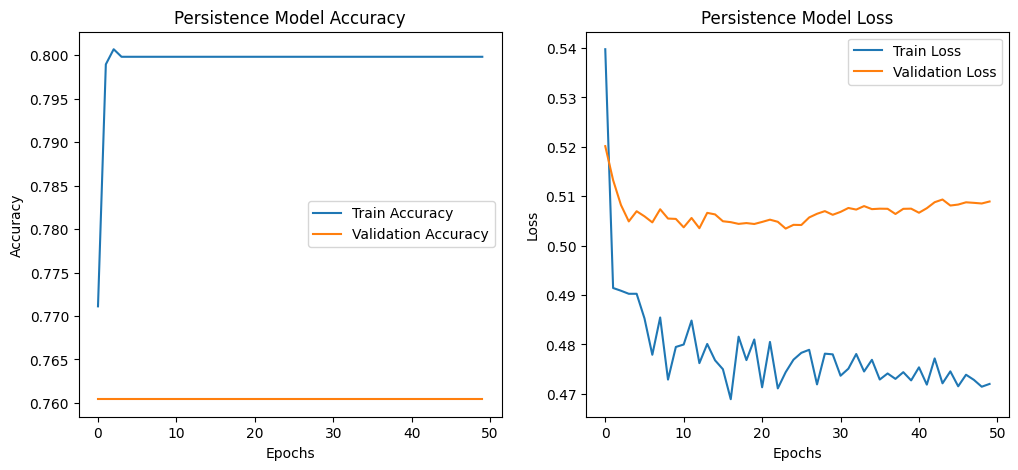

In [29]:
persistence_model_accuracy = model.history.history['accuracy']
persistence_model_val_accuracy = model.history.history['val_accuracy']
persistence_model_loss = model.history.history['loss']
persistence_model_val_loss = model.history.history['val_loss']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(persistence_model_accuracy, label='Train Accuracy')
plt.plot(persistence_model_val_accuracy, label='Validation Accuracy')
plt.title('Persistence Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(persistence_model_loss, label='Train Loss')
plt.plot(persistence_model_val_loss, label='Validation Loss')
plt.title('Persistence Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


# Neural Network for Academic Performance.

In [30]:
model_academic = Sequential()
model_academic.add(Dense(32, activation='relu', input_shape=(X_train_academic.shape[1],)))
model_academic.add(Dense(16, activation='relu'))
model_academic.add(Dense(1, activation='linear')) # for binary classification

model_academic.summary()


/opt/anaconda3/envs/sklearn-env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 705 (2.75 KB)

 Trainable params: 705 (2.75 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
model_academic.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae']) # Added MAE as a metric for regression
model_academic.fit(
    X_train_academic, 
    y_train_academic, 
    epochs=50, 
    batch_size=10, 
    validation_data=(X_test_academic, y_test_academic)
)


Epoch 1/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 5.2736 - mae: 2.0687 - val_loss: 2.0447 - val_mae: 1.2577
Epoch 2/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 624us/step - loss: 1.1973 - mae: 0.8921 - val_loss: 0.8308 - val_mae: 0.7117
Epoch 3/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 560us/step - loss: 0.7719 - mae: 0.6895 - val_loss: 0.6343 - val_mae: 0.6167
Epoch 4/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 551us/step - loss: 0.6307 - mae: 0.6106 - val_loss: 0.5174 - val_mae: 0.5532
Epoch 5/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 547us/step - loss: 0.5454 - mae: 0.5564 - val_loss: 0.4480 - val_mae: 0.5146
Epoch 6/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 546us/step - loss: 0.5018 - mae: 0.5276 - val_loss: 0.4114 - val_mae: 0.4931
Epoch 7/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 604us/step - loss: 0.4802 - mae: 0.5123 - val_loss: 0.3812 - val_mae: 0.4724
Epoch 8/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 657us/step - loss: 0.4653 - mae: 0.4954 - val_loss: 0.3679 - val_mae: 0.4530
Epoch 9/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s

## Academic Model Visualization

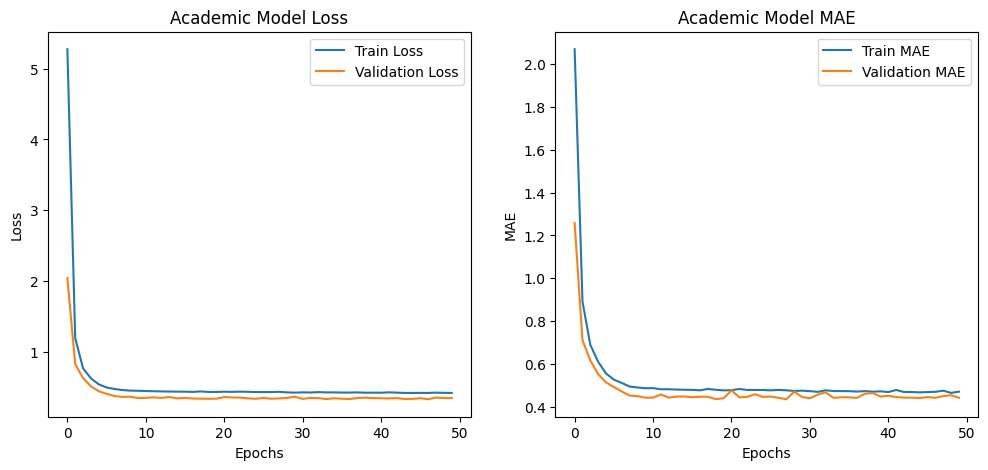

In [32]:
academic_model_loss = model_academic.history.history['loss']
academic_model_val_loss = model_academic.history.history['val_loss']
academic_model_mae = model_academic.history.history['mae']
academic_model_val_mae = model_academic.history.history['val_mae']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(academic_model_loss, label='Train Loss')
plt.plot(academic_model_val_loss, label='Validation Loss')
plt.title('Academic Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(academic_model_mae, label='Train MAE')
plt.plot(academic_model_val_mae, label='Validation MAE')
plt.title('Academic Model MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()

## Saving the Model

In [33]:
model.save('output/persistence_model.h5')

model_academic.save('output/academic_model.h5')

print("Models and Scalars saved successfully!")

Models and Scalars saved successfully!
